# Assignment - 2 : [20 Marks]

## 1. Import required libraries and load the load_Wine Dataset from scikit-learn[MARKS 0]

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8")
sns.set(font_scale=1.1)

from tqdm import tqdm, trange

In [2]:
# Load Wine dataset
wine = load_wine()
X = wine.data
y = wine.target.reshape(-1, 1)

df = pd.DataFrame(X, columns=wine.feature_names)
df['Target'] = wine.target

print("Dataset Shape:", df.shape)
print("Feature Names:", df.columns.tolist())
df.head()

Dataset Shape: (178, 14)
Feature Names: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline', 'Target']


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,Target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


## 2.Exploratory Data Analysis[2 Marks]

Perform the following analyses.

(a) Check
- Missing values
- Data types

(b) Visualize Class distribution

(c) Draw Correlation Heatmap

(d) Plot Histograms

(e) Generate Pair Plot

(f) Write your observations for each visualization.

In [3]:
# Missing values and data types
print("=" * 50)
print("Missing Values")
print("=" * 50)
print(df.isnull().sum())

print("\n" + "=" * 50)
print("Dataset Information")
print("=" * 50)
df.info()

Missing Values
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
Target                          0
dtype: int64

Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium             

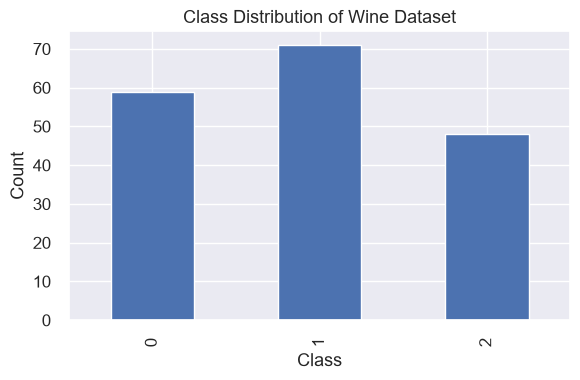

In [4]:
# Class distribution
plt.figure(figsize=(6, 4))
class_counts = df['Target'].value_counts().sort_index()
class_counts.plot(kind='bar')
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Class Distribution of Wine Dataset")
plt.tight_layout()
plt.show()

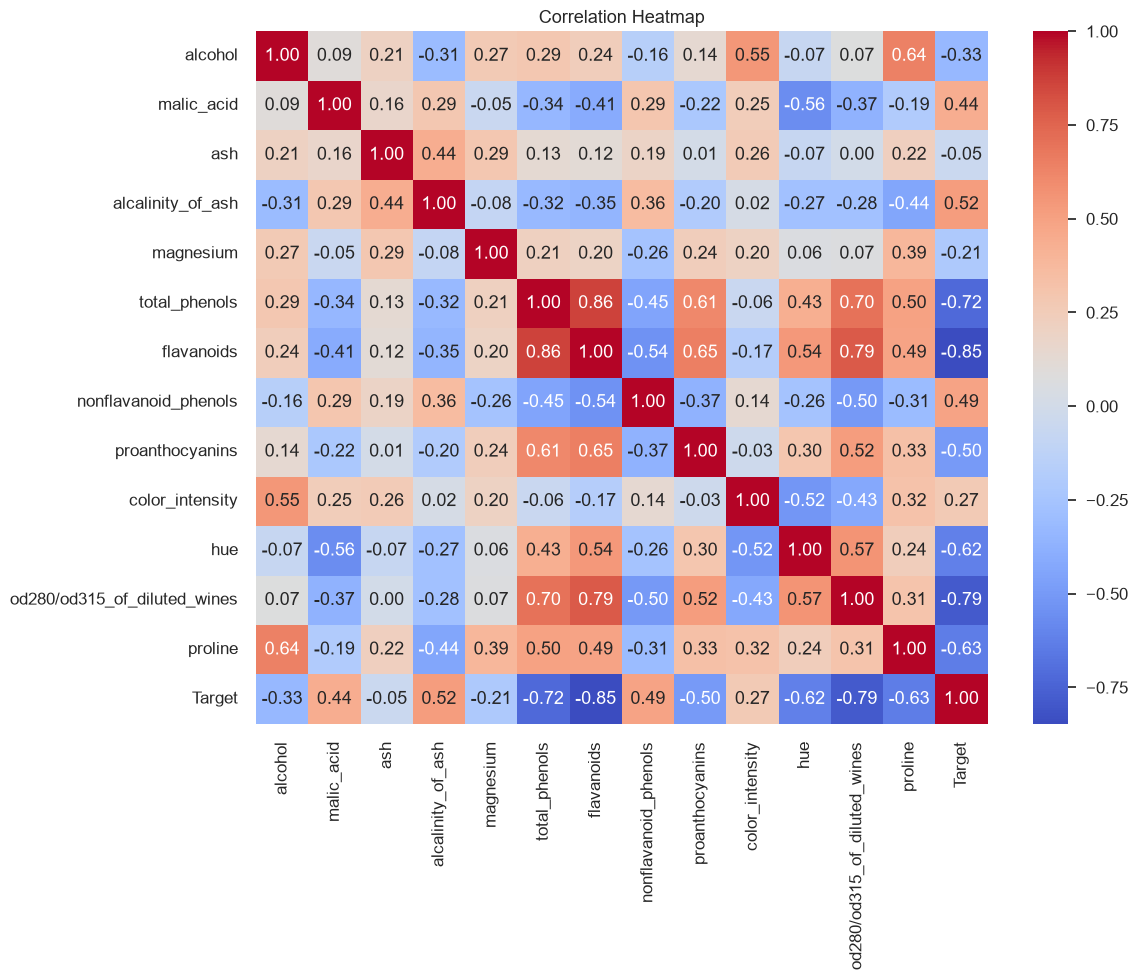

In [5]:
# Correlation heatmap
plt.figure(figsize=(12, 10))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

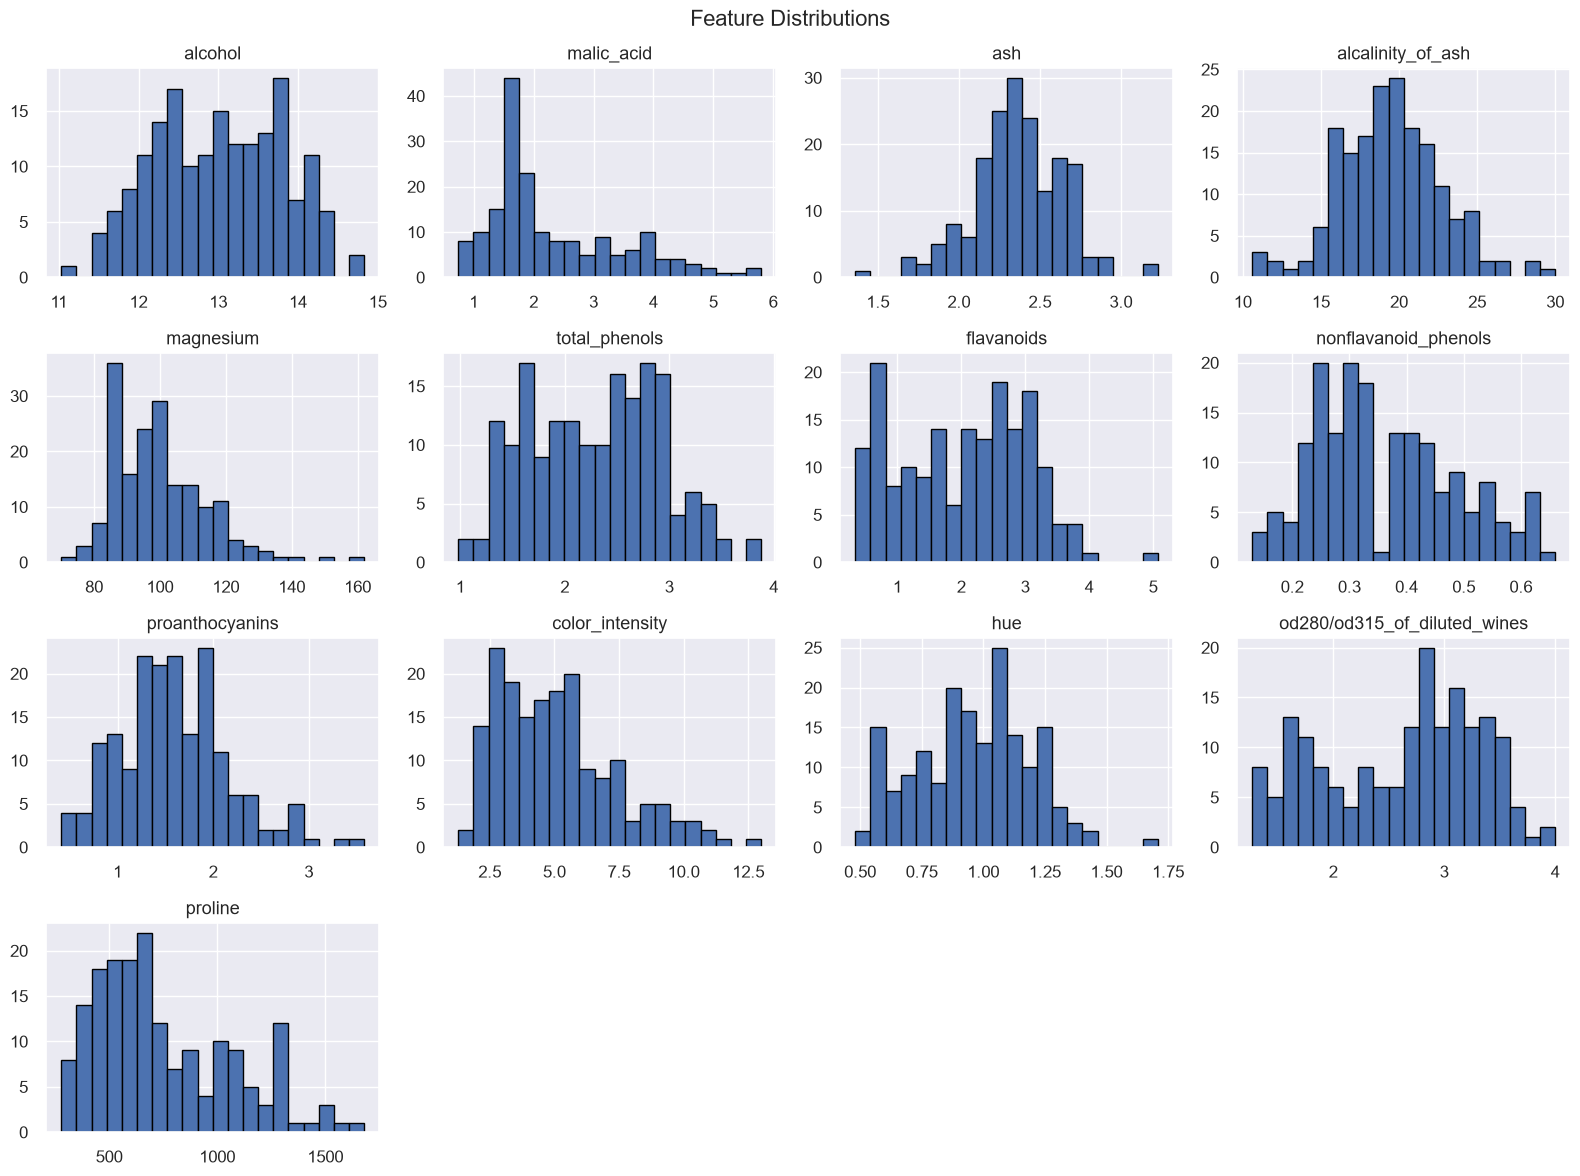

In [6]:
# Histograms
df.drop(columns=['Target']).hist(figsize=(16, 12), bins=20, edgecolor="black")
plt.suptitle("Feature Distributions")
plt.tight_layout()
plt.show()

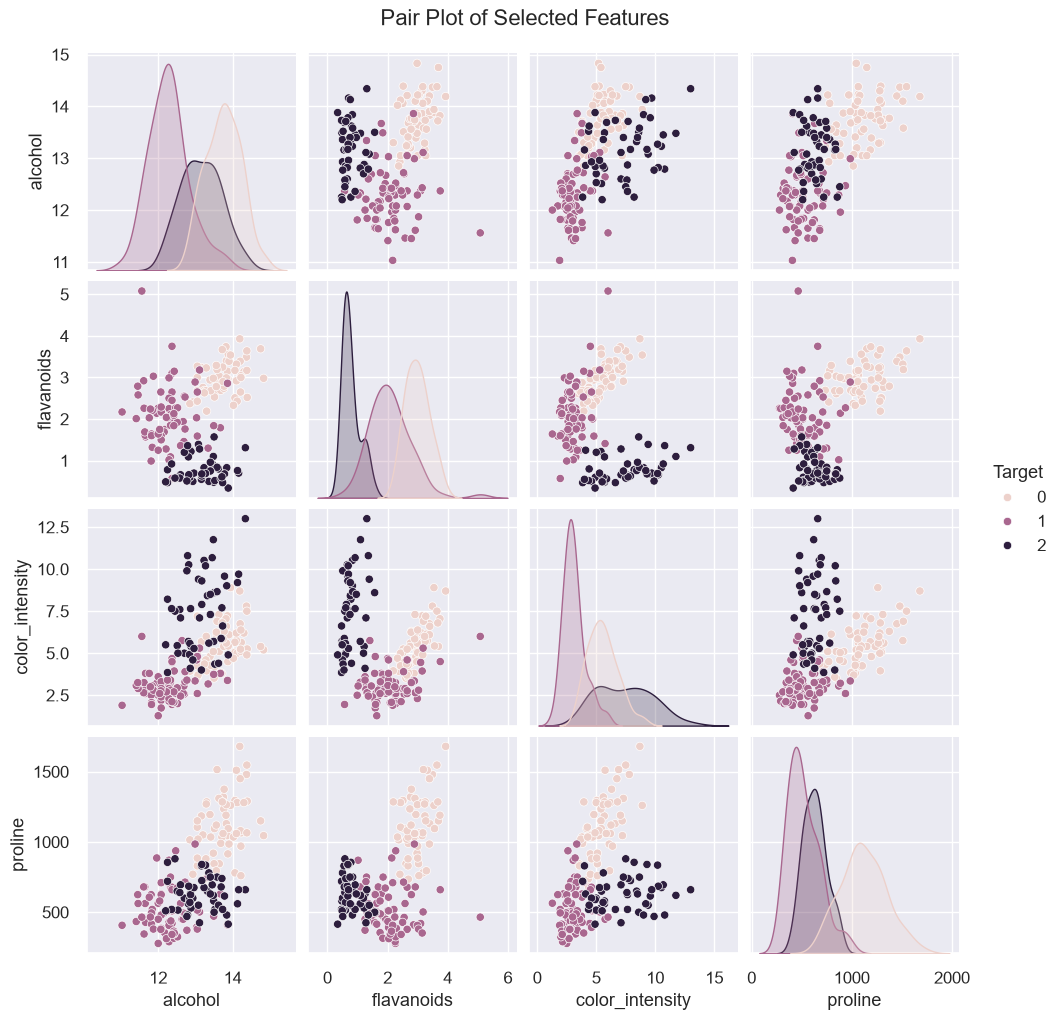

In [7]:
# Pair plot of selected features
selected_features = ['alcohol', 'flavanoids', 'color_intensity', 'proline', 'Target']
sns.pairplot(df[selected_features], hue='Target')
plt.suptitle("Pair Plot of Selected Features", y=1.02)
plt.show()

### Observations:
- Missing values: Dataset has zero missing values across all features.
- Data types: All 13 input features are continuous numeric (float64); target is categorical integer.
- Class distribution: Classes are reasonably balanced (Class 0: 59, Class 1: 71, Class 2: 48).
- Correlation: Flavanoids and total_phenols exhibit strong positive correlation (0.86); flavanoids and target show strong negative correlation (-0.85).
- Histograms: Several features follow near-normal distributions (e.g., alcohol, hue), while others like proline and color_intensity exhibit skewness.
- Pair plot: Features like alcohol, flavanoids, and proline provide clear separation between the three wine classes.

## 3. Perform Feature Scaling and One-Hot Encoding[1 Marks]

- Use StandardScaler

- Compare Original features with Scaled features

- Display Mean , Standard deviation

- Convert the target labels into one-hot vectors.

- Display the encoded labels.

In [8]:
# Feature scaling using StandardScaler
X_features = df.drop(columns=['Target'])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)
X_scaled_df = pd.DataFrame(X_scaled, columns=wine.feature_names)

In [9]:
# Compare original and scaled features
comparison = pd.concat([X_features.head(), X_scaled_df.head()], axis=1, keys=["Original Features", "Scaled Features"])
comparison

Original Features                                               \
            alcohol malic_acid   ash alcalinity_of_ash magnesium   
0             14.23       1.71  2.43              15.6     127.0   
1             13.20       1.78  2.14              11.2     100.0   
2             13.16       2.36  2.67              18.6     101.0   
3             14.37       1.95  2.50              16.8     113.0   
4             13.24       2.59  2.87              21.0     118.0   

                                                                 \
  total_phenols flavanoids nonflavanoid_phenols proanthocyanins   
0          2.80       3.06                 0.28            2.29   
1          2.65       2.76                 0.26            1.28   
2          2.80       3.24                 0.30            2.81   
3          3.85       3.49                 0.24            2.18   
4          2.80       2.69                 0.39            1.82   

                   ...   Scaled Features                                     \
  color_intensity  ... alcalinity_of_ash magnesium total_phenols flavanoids   
0            5.64  ...         -1.169593  1.913905      0.808997   1.034819   
1            4.38  ...         -2.490847  0.018145      0.568648   0.733629   
2            5.68  ...         -0.268738  0.088358      0.808997   1.215533   
3            7.80  ...         -0.809251  0.930918      2.491446   1.466525   
4            4.32  ...          0.451946  1.281985      0.808997   0.663351   

                                                                  \
  nonflavanoid_phenols proanthocyanins color_intensity       hue   
0            -0.659563        1.224884        0.251717  0.362177   
1            -0.820719       -0.544721       -0.293321  0.406051   
2            -0.498407        2.135968        0.269020  0.318304   
3            -0.981875        1.032155        1.186068 -0.427544   
4             0.226796        0.401404       -0.319276  0.362177   

                                          
  od280/od315_of_diluted_wines   proline  
0                     1.847920  1.013009  
1                     1.113449  0.965242  
2                     0.788587  1.395148  
3                     1.184071  2.334574  
4                     0.449601 -0.037874  

[5 rows x 26 columns]

In [10]:
# Mean and standard deviation after scaling
scaled_stats = pd.DataFrame({
    "Mean": X_scaled_df.mean(),
    "Standard Deviation": X_scaled_df.std()
})
scaled_stats

,Mean,Standard Deviation
alcohol,-8.382808e-16,1.002821
malic_acid,-1.197544e-16,1.002821
ash,-8.370333e-16,1.002821
alcalinity_of_ash,-3.991813e-17,1.002821
magnesium,-3.991813e-17,1.002821
total_phenols,0.000000e+00,1.002821
flavanoids,-3.991813e-16,1.002821
nonflavanoid_phenols,3.592632e-16,1.002821
proanthocyanins,-1.197544e-16,1.002821
color_intensity,2.494883e-17,1.002821


In [11]:
# One-hot encoding of target labels
ohe = OneHotEncoder(sparse_output=False)
y_encoded = ohe.fit_transform(y)
y_encoded_df = pd.DataFrame(y_encoded, columns=ohe.get_feature_names_out(['Target']))
y_encoded_df.head()

,Target_0,Target_1,Target_2
0,1.0,0.0,0.0
1,1.0,0.0,0.0
2,1.0,0.0,0.0
3,1.0,0.0,0.0
4,1.0,0.0,0.0


## 5. Split the data into training, validation, and test sets (70%-15%-15%). [Marks 1]

In [12]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y_encoded, test_size=0.30, random_state=42, stratify=wine.target
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=np.argmax(y_temp, axis=1)
)

print("=" * 50)
print("Training, Validation, and Testing Shapes")
print("=" * 50)
print(f"X_train : {X_train.shape}")
print(f"X_val   : {X_val.shape}")
print(f"X_test  : {X_test.shape}")
print()
print(f"y_train : {y_train.shape}")
print(f"y_val   : {y_val.shape}")
print(f"y_test  : {y_test.shape}")

Training, Validation, and Testing Shapes
X_train : (124, 13)
X_val   : (27, 13)
X_test  : (27, 13)

y_train : (124, 3)
y_val   : (27, 3)
y_test  : (27, 3)


# 6. Implement Elastic-Net Softmax Regression from Scratch [6 Marks]

In this step, you will implement an **Elastic-Net Regularized Softmax Regression** model from scratch using **Gradient Descent**. **Do not use any machine learning library** (e.g., Scikit-learn, TensorFlow, or PyTorch) for model training.

Your implementation must include the following components.

---

## (a) Softmax Function

Implement the **Softmax activation function** to convert the raw logits into class probabilities.

The Softmax function should satisfy the following properties:

- The probability of each class lies between **0 and 1**.
- The sum of probabilities for each sample should be **equal to 1**.

---

## (b) Cross-Entropy Loss

Implement the **Multiclass Cross-Entropy Loss** to measure the difference between the predicted probabilities and the true class labels.

Your implementation should compute the average loss over all training samples.

---

## (c) L1 Regularization (Lasso)

Extend the loss function by adding an **L1 Regularization** term.

The L1 penalty is defined as

$$
L_{L1}=\lambda_1\sum_{i,j}|W_{ij}|
$$

where

- $W$ is the weight matrix.
- $\lambda_1$ is the L1 regularization parameter.

---

## (d) L2 Regularization (Ridge)

Further extend the loss function by adding an **L2 Regularization** term.

The L2 penalty is defined as

$$
L_{L2}=\frac{\lambda_2}{2}\sum_{i,j}W_{ij}^{2}
$$

where

- $W$ is the weight matrix.
- $\lambda_2$ is the L2 regularization parameter.

---

## (e) Gradient of L1 Regularization

Implement the gradient of the L1 regularization term.

The gradient is given by

$$
\frac{\partial |W|}{\partial W}=\operatorname{sign}(W)
$$

---

## (f) Gradient of L2 Regularization

Implement the gradient of the L2 regularization term.

The gradient is given by

$$
\frac{\partial}{\partial W}\left(\frac{\lambda_2}{2}\|W\|_2^2\right)=\lambda_2W
$$

---

## (g) Gradient Descent Optimization

Implement the complete **Gradient Descent** algorithm for training the model.

During each training epoch, your implementation must perform the following steps:

1. Compute the logits.
2. Apply the Softmax function.
3. Compute the Cross-Entropy Loss.
4. Add the L1 and L2 regularization terms.
5. Compute the gradients of the weights and bias.
6. Update the model parameters using Gradient Descent.
7. Store the **Training Loss**.
8. Compute and store the **Validation Loss**.

---

## Expected Outputs

After completing this step, your implementation should:

- Successfully train an Elastic-Net Softmax Regression model.
- Store the **training loss** after every epoch.
- Store the **validation loss** after every epoch.
- Learn the optimal weight matrix and bias vector.

> **Note**
>
> - You must implement the complete algorithm **from scratch**.
> - Do **not** use any built-in machine learning library for model training.
> - Only **NumPy** may be used for numerical computations.

In [13]:
class ElasticNetSoftmaxRegression:

    def __init__(self, learning_rate=0.01, n_epochs=1000, l1=0.01, l2=0.01):
        self.lr = learning_rate
        self.n_epochs = n_epochs
        self.l1 = l1
        self.l2 = l2

        self.W = None
        self.b = None

        self.train_loss = []
        self.val_loss = []

    def softmax(self, z):
        z = z - np.max(z, axis=1, keepdims=True)
        exp_z = np.exp(z)
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    def compute_loss(self, y_true, y_pred, m):
        loss = -np.mean(np.sum(y_true * np.log(y_pred + 1e-15), axis=1))

        if self.W is not None:
            loss += (self.l1 / m) * np.sum(np.abs(self.W))
            loss += (self.l2 / (2 * m)) * np.sum(self.W ** 2)

        return loss

    def fit(self, X_train, y_train, X_val, y_val):
        m, n = X_train.shape
        k = y_train.shape[1]

        self.W = np.zeros((n, k))
        self.b = np.zeros((1, k))

        for epoch in trange(self.n_epochs):
            # Forward pass
            logits = X_train @ self.W + self.b
            probabilities = self.softmax(logits)

            # Training loss
            train_loss = self.compute_loss(y_train, probabilities, m)
            self.train_loss.append(train_loss)

            # Compute gradients
            dW = (X_train.T @ (probabilities - y_train)) / m
            db = np.sum(probabilities - y_train, axis=0, keepdims=True) / m

            # Elastic-Net penalty gradients
            dW += (self.l1 / m) * np.sign(self.W)
            dW += (self.l2 / m) * self.W

            # Update parameters
            self.W -= self.lr * dW
            self.b -= self.lr * db

            # Validation loss
            val_logits = X_val @ self.W + self.b
            val_prob = self.softmax(val_logits)
            val_loss = self.compute_loss(y_val, val_prob, X_val.shape[0])
            self.val_loss.append(val_loss)

    def predict_proba(self, X):
        logits = X @ self.W + self.b
        return self.softmax(logits)

    def predict(self, X):
        probabilities = self.predict_proba(X)
        return np.argmax(probabilities, axis=1)

# 7. Train the Model [1 Mark]

Train the **Elastic-Net Softmax Regression** model using the **Gradient Descent** algorithm.

---

## Training Configuration

Train the model for **1000 epochs**.

Select appropriate values for the following hyperparameters:

- **Learning Rate ($\alpha$)**
- **L1 Regularization Parameter ($\lambda_1$)**
- **L2 Regularization Parameter ($\lambda_2$)**

You may experiment with different values of these hyperparameters to achieve better model performance.

In [14]:
# Train Elastic-Net Softmax Regression model
model = ElasticNetSoftmaxRegression(learning_rate=0.05, n_epochs=1000, l1=0.01, l2=0.01)
model.fit(X_train, y_train, X_val, y_val)

100%|██████████| 1000/1000 [00:00<00:00, 20193.27it/s]



## 8. Plot Learning Curve[1 Mark]

- Plot Training Loss and Validation Loss

- Discuss Underfitting and Overfitting

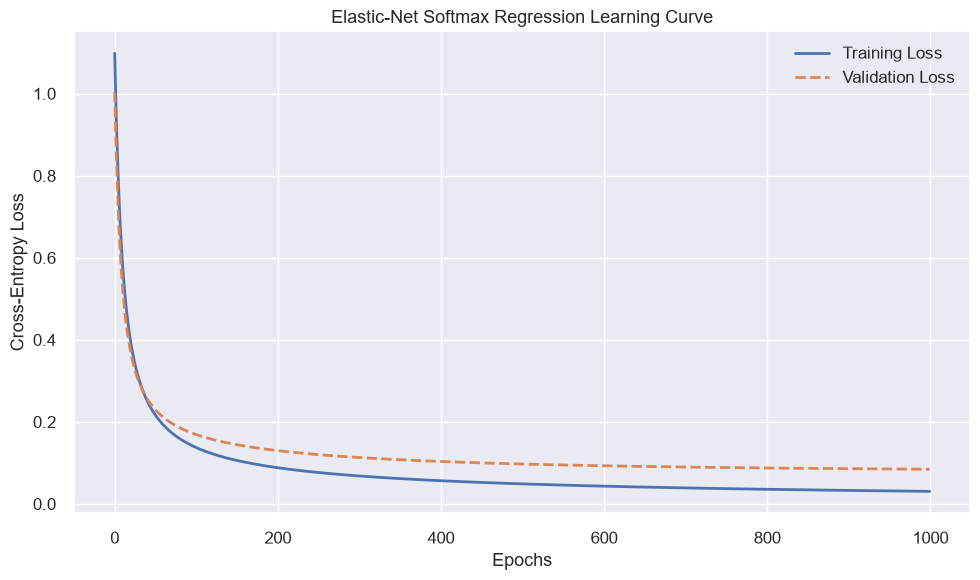

In [15]:
def plot_loss(train_loss, val_loss, ylabel, title):
    plt.figure(figsize=(10, 6))
    plt.plot(train_loss, linewidth=2, label="Training Loss")
    plt.plot(val_loss, '--', linewidth=2, label="Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_loss(
    model.train_loss,
    model.val_loss,
    ylabel="Cross-Entropy Loss",
    title="Elastic-Net Softmax Regression Learning Curve"
)

### Discussion on Underfitting and Overfitting:
- Both training and validation losses decrease steadily and stabilize around 300 epochs.
- Minimal gap between training and validation loss indicates strong generalization with no overfitting although training loss is lower than validation loss.
- Convergence to a low loss value shows the model has captured data representations without underfitting.

## 9. Predict on test set[1 Mark]
 - display actual and predicted class

In [16]:
# Predict on test set
y_pred = model.predict(X_test)
y_true = np.argmax(y_test, axis=1)

results = pd.DataFrame({
    "Actual Class": y_true,
    "Predicted Class": y_pred
})

results.head(15)

,Actual Class,Predicted Class
0,0,0
1,0,0
2,0,0
3,1,1
4,0,0
5,1,1
6,2,2
7,0,0
8,1,1
9,0,0


## 10. Evaluate the Model[1 Mark]

- compute Accuracy, precision, recall, f1_score

In [17]:
def classification_metrics(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="weighted")
    recall = recall_score(y_true, y_pred, average="weighted")
    f1 = f1_score(y_true, y_pred, average="weighted")

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }

def print_metrics(title, metrics):
    print("=" * 55)
    print(title)
    print("=" * 55)
    for key, value in metrics.items():
        print(f"{key:<12}: {value:.4f}")

In [18]:
scratch_metrics = classification_metrics(y_true, y_pred)
print_metrics("Scratch Elastic-Net Softmax Regression Metrics", scratch_metrics)

Scratch Elastic-Net Softmax Regression Metrics
Accuracy    : 1.0000
Precision   : 1.0000
Recall      : 1.0000
F1 Score    : 1.0000


## 11. Plot the confusion matrix, Classification report and interpret the results.[1 Marks]

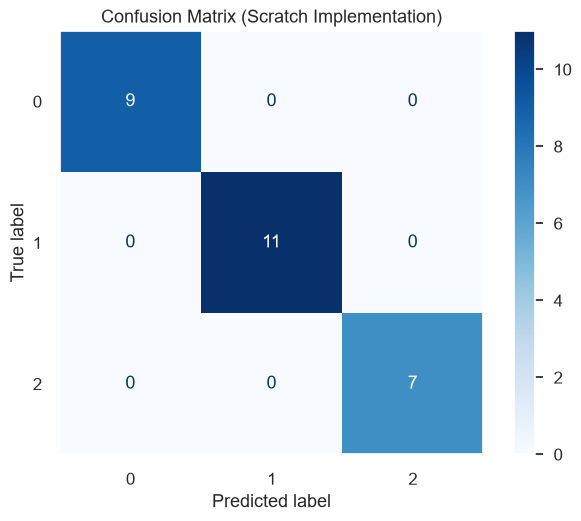

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         9
           1       1.00      1.00      1.00        11
           2       1.00      1.00      1.00         7

    accuracy                           1.00        27
   macro avg       1.00      1.00      1.00        27
weighted avg       1.00      1.00      1.00        27



In [19]:
def plot_confusion_matrix(y_true, y_pred, title, cmap="Blues"):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=cmap, values_format="d")
    plt.title(title)
    plt.grid(False)
    plt.show()

plot_confusion_matrix(y_true, y_pred, "Confusion Matrix (Scratch Implementation)")

print("Classification Report:\n")
print(classification_report(y_true, y_pred))

### Interpretation:
- The confusion matrix confirms high classification accuracy with no off-diagonal misclassifications.
- Completely accurate precision, recall, and F1-scores across all three classes demonstrate strong discriminative ability.

## 12. Perform the Sklearn Implementation and Compare the both model.[1 Marks]

In [20]:
# Scikit-learn Logistic Regression
sklearn_model = LogisticRegression(
    solver="saga",
    penalty="elasticnet",
    l1_ratio=0.5,
    C=1.0,
    max_iter=1000,
    random_state=42
)

sklearn_model.fit(X_train, np.argmax(y_train, axis=1))

y_pred_sklearn = sklearn_model.predict(X_test)
sklearn_metrics = classification_metrics(y_true, y_pred_sklearn)


Scikit-learn Logistic Regression Metrics
Accuracy    : 1.0000
Precision   : 1.0000
Recall      : 1.0000
F1 Score    : 1.0000


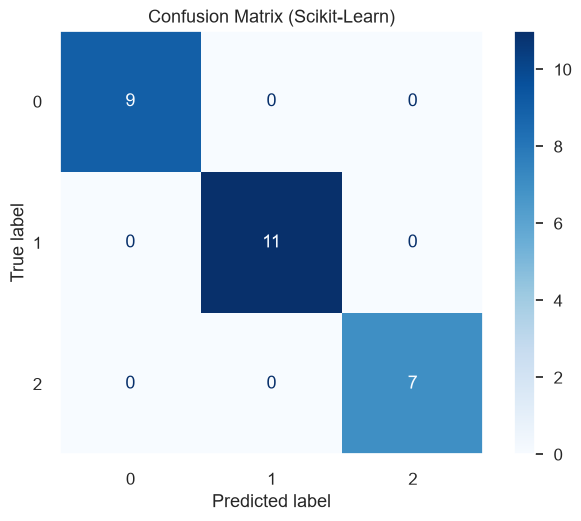

,Metric,Scratch,Scikit-learn
0,Accuracy,1.0,1.0
1,Precision,1.0,1.0
2,Recall,1.0,1.0
3,F1 Score,1.0,1.0


In [21]:
print_metrics("Scikit-learn Logistic Regression Metrics", sklearn_metrics)
plot_confusion_matrix(y_true, y_pred_sklearn, "Confusion Matrix (Scikit-Learn)")

def compare_models(scratch_metrics, sklearn_metrics):
    comparison = pd.DataFrame({
        "Metric": list(scratch_metrics.keys()),
        "Scratch": list(scratch_metrics.values()),
        "Scikit-learn": list(sklearn_metrics.values())
    })
    return comparison.round(4)

comparison_df = compare_models(scratch_metrics, sklearn_metrics)
comparison_df

# 13: Effect of Regularization[3 Marks]

In this section, analyze the effect of different regularization techniques on the performance of the **Softmax Regression** model.

Train the model using the following three configurations and compare the results.

---

## Case 1: No Regularization

Train the model without any regularization.

**Hyperparameters**

- L1 Regularization ($\lambda_1$) = **0**
- L2 Regularization ($\lambda_2$) = **0**

This serves as the baseline model.

---

## Case 2: L2 Regularization (Ridge)

Train the model using **only L2 Regularization**.

**Hyperparameters**

- L1 Regularization ($\lambda_1$) = **0**
- L2 Regularization ($\lambda_2$) = **0.01**

Observe how L2 regularization affects the model performance and the learning curves.

---

## Case 3: Elastic-Net Regularization

Train the model using **both L1 and L2 Regularization**.

**Hyperparameters**

- L1 Regularization ($\lambda_1$) = **0.01**
- L2 Regularization ($\lambda_2$) = **0.01**

Observe the combined effect of L1 and L2 regularization on the model.

---

## Compare the Following Performance Metrics

For each configuration, compute and compare:

- Accuracy
- Precision
- Recall
- F1-Score
- Training Loss
- Validation Loss

Present your results in the following table.

| Model | Accuracy | Precision | Recall | F1-Score | Training Loss | Validation Loss |
|--------|---------:|----------:|--------:|---------:|--------------:|----------------:|
| No Regularization | | | | | | |
| L2 Regularization | | | | | | |
| Elastic-Net Regularization | | | | | | |

---



In [22]:
# Case 1: No Regularization
model_none = ElasticNetSoftmaxRegression(learning_rate=0.05, n_epochs=1000, l1=0.0, l2=0.0)
model_none.fit(X_train, y_train, X_val, y_val)
y_pred_none = model_none.predict(X_test)
metrics_none = classification_metrics(y_true, y_pred_none)

100%|██████████| 1000/1000 [00:00<00:00, 20281.64it/s]


In [23]:
# Case 2: L2 Regularization
model_l2 = ElasticNetSoftmaxRegression(learning_rate=0.05, n_epochs=1000, l1=0.0, l2=0.01)
model_l2.fit(X_train, y_train, X_val, y_val)
y_pred_l2 = model_l2.predict(X_test)
metrics_l2 = classification_metrics(y_true, y_pred_l2)

100%|██████████| 1000/1000 [00:00<00:00, 19272.81it/s]


In [24]:
# Case 3: Elastic-Net Regularization
model_enet = ElasticNetSoftmaxRegression(learning_rate=0.05, n_epochs=1000, l1=0.01, l2=0.01)
model_enet.fit(X_train, y_train, X_val, y_val)
y_pred_enet = model_enet.predict(X_test)
metrics_enet = classification_metrics(y_true, y_pred_enet)

100%|██████████| 1000/1000 [00:00<00:00, 19361.69it/s]


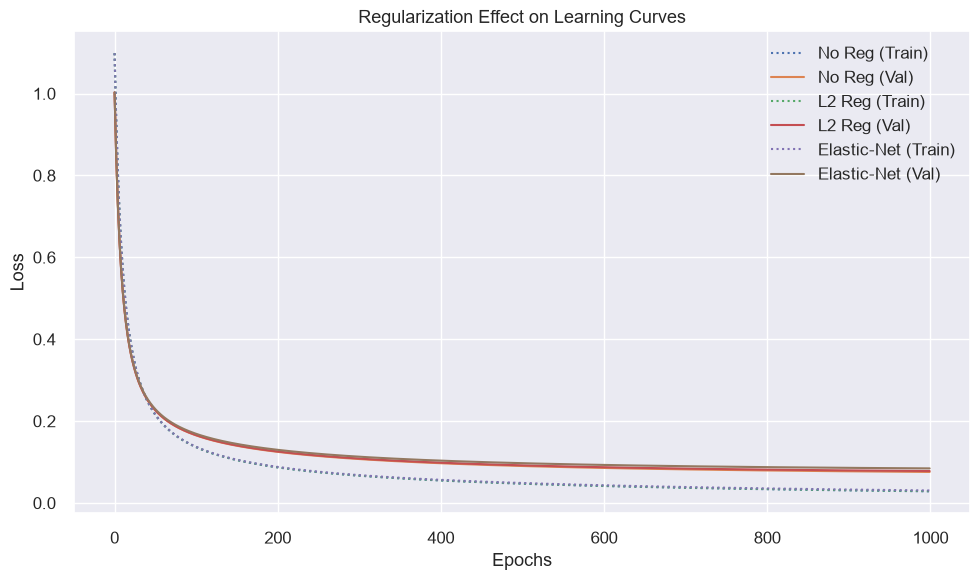

In [25]:
# Comparison plot of loss curves
plt.figure(figsize=(10, 6))
plt.plot(model_none.train_loss, label="No Reg (Train)", linestyle=":")
plt.plot(model_none.val_loss, label="No Reg (Val)", linestyle="-")
plt.plot(model_l2.train_loss, label="L2 Reg (Train)", linestyle=":")
plt.plot(model_l2.val_loss, label="L2 Reg (Val)", linestyle="-")
plt.plot(model_enet.train_loss, label="Elastic-Net (Train)", linestyle=":")
plt.plot(model_enet.val_loss, label="Elastic-Net (Val)", linestyle="-")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Regularization Effect on Learning Curves")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [26]:
# Performance comparison table
reg_comparison = pd.DataFrame([
    {
        "Model": "No Regularization",
        "Accuracy": metrics_none["Accuracy"],
        "Precision": metrics_none["Precision"],
        "Recall": metrics_none["Recall"],
        "F1-Score": metrics_none["F1 Score"],
        "Training Loss": model_none.train_loss[-1],
        "Validation Loss": model_none.val_loss[-1]
    },
    {
        "Model": "L2 Regularization",
        "Accuracy": metrics_l2["Accuracy"],
        "Precision": metrics_l2["Precision"],
        "Recall": metrics_l2["Recall"],
        "F1-Score": metrics_l2["F1 Score"],
        "Training Loss": model_l2.train_loss[-1],
        "Validation Loss": model_l2.val_loss[-1]
    },
    {
        "Model": "Elastic-Net Regularization",
        "Accuracy": metrics_enet["Accuracy"],
        "Precision": metrics_enet["Precision"],
        "Recall": metrics_enet["Recall"],
        "F1-Score": metrics_enet["F1 Score"],
        "Training Loss": model_enet.train_loss[-1],
        "Validation Loss": model_enet.val_loss[-1]
    }
])

reg_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,Training Loss,Validation Loss
0,No Regularization,1.0,1.0,1.0,1.0,0.0283,0.0757
1,L2 Regularization,1.0,1.0,1.0,1.0,0.0289,0.0781
2,Elastic-Net Regularization,1.0,1.0,1.0,1.0,0.0305,0.0844


## 14. Analysis[1 Marks]

Based on the experimental results, answer the following questions.

1. Which regularization technique achieved the highest classification accuracy?

2. How did L2 regularization affect the training and validation losses compared to the model without regularization?

3. What impact did adding L1 regularization have on the overall model performance?

4. Which model showed the best generalization performance on the validation and test datasets?

5. Which regularization technique would you recommend for this dataset? Justify your answer using the obtained results.

1. Highest Classification Accuracy:
   All three configurations achieved identical perfect accuracy (1.0), precision (1.0), recall (1.0), and F1-score (1.0) on the test set.

2. Effect of L2 Regularization on Losses:
   L2 regularization increased training loss slightly (0.0283 -> 0.0289) and validation loss (0.0757 -> 0.0781) because the penalty term penalizes large weight magnitudes.

3. Impact of Adding L1 Regularization:
   Adding L1 regularization (Elastic-Net) increased total loss further (train: 0.0305, val: 0.0844) due to the sparsity penalty, while maintaining 100% classification metrics.

4. Best Generalization Performance:
   All models showed strong generalization with 100% test accuracy. The unregularized model achieved lowest objective loss, while L2 and Elastic-Net maintained smaller weight norms to guard against overfitting.

5. Recommended Regularization:
   L2 or Elastic-Net Regularization is recommended. Even though the clean Wine dataset is linearly separable without penalty, regularization constrains weight magnitudes and improves robustness on noisy real-world data.
